# CME Futures: Tabular Deep Learning (TabM)

TabM applies a rank-1 adapter MLP ensemble to the same flat feature matrix
used by GBM. For CME futures, the question is whether TabM's learned feature
interactions offer any advantage over GBM's tree-based splits for the
sector-structured 30-product cross-section.

**Learning Objectives**:
- Train TabM (small/medium/large) on walk-forward folds with IC checkpoints
- Compare TabM to GBM and linear baselines on 21d futures returns
- Assess whether learned embeddings capture sector structure
- Generate backtesting-ready predictions

**Book Reference**: Chapter 12, Section 12.3 (Deep Learning Alternatives)

**Prerequisites**: `03_financial_features.py`, `04_temporal.py`, [`05_evaluation`](05_evaluation.ipynb)

In [1]:
"""Tabular DL Grid Search — TabM / TabPFN via walk-forward CV."""

import warnings

import plotly.graph_objects as go
import polars as pl
import torch
import yaml

import utils.style as style
from case_studies.utils.tabular_dl import run_tabm_cv
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "cme_futures"
PRIMARY_LABEL = ""  # Read from setup.yaml if empty
MAX_SYMBOLS = 0
FORCE_RETRAIN = False  # Set True to retrain configs that already have complete hashes
PREDICTION_SPLIT = "validation"
N_EPOCHS = 100
BATCH_SIZE = 4096
MAX_FOLDS = 0

In [3]:
# Resolve config from setup.yaml
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]
    print(f"Label from setup.yaml: {PRIMARY_LABEL}")
else:
    print(f"Label override: {PRIMARY_LABEL}")

tdl_config = setup.get("modeling", {}).get("tabular_dl", {})
MODELS = tdl_config.get("models", ["tabm"])
DEVICE = tdl_config.get("device", "gpu")

include_tabpfn = "tabpfn" in MODELS

device_str = "cuda" if DEVICE == "gpu" and torch.cuda.is_available() else "cpu"
print(f"Case study: {CASE_STUDY_ID}")
print(f"Device: {device_str} | Models: {MODELS}")
print(f"Epochs: {N_EPOCHS} | Batch: {BATCH_SIZE}")

Label from setup.yaml: fwd_ret_5d
Case study: cme_futures
Device: cuda | Models: ['tabm']
Epochs: 100 | Batch: 4096


## 1. Load Artifacts

Same modeling dataset as Ch11-12: 69 features, 30 CME products, 5 folds, all
trained on the `fwd_ret_5d` primary label — the label the linear, GBM, and
latent-factor families also use, so the IC comparison in `12_model_analysis`
is like-for-like.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else "product"
splits = mds.splits
if MAX_FOLDS:
    splits = splits[:MAX_FOLDS]
n_features = len(feature_names)

print(f"Dataset: {len(dataset):,} rows × {n_features} features")
print(f"Label: {label_col} | Date: {date_col} | Entity: {entity_col}")
for s in splits:
    print(
        f"  Fold {s['fold']}: train {str(s['train_start'])[:10]}\u2192{str(s['train_end'])[:10]}  "
        f"val {str(s['val_start'])[:10]}\u2192{str(s['val_end'])[:10]}"
    )

Dataset: 112,726 rows × 69 features
Label: fwd_ret_5d | Date: timestamp | Entity: product
  Fold 0: train 2015-01-02→2022-12-22  val 2023-01-03→2023-12-29
  Fold 1: train 2014-01-02→2021-12-23  val 2022-01-03→2022-12-30
  Fold 2: train 2012-12-31→2020-12-24  val 2021-01-05→2021-12-31
  Fold 3: train 2012-01-03→2019-12-26  val 2020-01-06→2021-01-04
  Fold 4: train 2011-02-01→2018-12-26  val 2019-01-04→2020-01-03


## 1b. Data Diagnostics

In [5]:
dataset_pd = dataset.to_pandas()

label_nans = dataset_pd[label_col].isna().sum()
feat_nan_rate = dataset_pd[feature_names].isna().mean().mean()
n_entities = dataset_pd[entity_col].nunique()

print(f"Entities: {n_entities}")
print(f"Label NaN: {label_nans:,} / {len(dataset_pd):,} ({label_nans / len(dataset_pd):.1%})")
print(f"Feature NaN rate: {feat_nan_rate:.1%}")

Entities: 30
Label NaN: 0 / 112,726 (0.0%)
Feature NaN rate: 6.9%


## 2. Build Grid

TabM configurations: small (64h×4m), medium (128h×8m), large (256h×16m).
Optionally includes TabPFN (foundation model, subsampled to 2K training rows).

In [6]:
tabdl_configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, "tabular_dl")

# Apply Papermill overrides to configs (test mode: fewer epochs)
for cfg in tabdl_configs:
    if cfg.get("n_epochs", 100) != N_EPOCHS:
        cfg["n_epochs"] = N_EPOCHS
    if cfg.get("batch_size", 4096) != BATCH_SIZE:
        cfg["batch_size"] = BATCH_SIZE

print(f"Grid: {len(tabdl_configs)} configs × {N_EPOCHS} epochs × {len(splits)} folds")
for cfg in tabdl_configs:
    name = cfg["config_name"]
    params = cfg.get("params", {})
    if name.startswith("tabpfn"):
        print(f"  {name:15s}  max_samples={params.get('max_samples', 2000)}")
    else:
        print(
            f"  {name:15s}  hidden={params['hidden_dim']}  "
            f"members={params['n_members']}  dropout={params['dropout']}"
        )

Grid: 3 configs × 100 epochs × 5 folds
  tabm_s           hidden=64  members=4  dropout=0.1
  tabm_m           hidden=128  members=8  dropout=0.1
  tabm_l           hidden=256  members=16  dropout=0.1


## 3. Run Tabular DL CV

Walk-forward training with IC evaluation at epoch checkpoints.

In [7]:
result = run_tabm_cv(
    dataset_pd,
    splits,
    feature_names=feature_names,
    label_col=label_col,
    date_col=date_col,
    entity_col=entity_col,
    configs=tabdl_configs,
    n_features=n_features,
    device=device_str,
    save_dir=CASE_DIR / "run_log" / "training" / "tabular_dl",
    register=True,
    force_retrain=FORCE_RETRAIN,
    prediction_split=PREDICTION_SPLIT,
    case_study=CASE_STUDY_ID,
    notebook="08_tabular_dl",
    temporal_by_fold=mds.temporal_by_fold,
    temporal_keys=mds.temporal_keys,
    temporal_feature_names=mds.temporal_feature_names,
)

  SKIP tabm_s                     (complete (hash=e4048096d142), split=validation)
  SKIP tabm_m                     (complete (hash=c55649ba2f04), split=validation)
  SKIP tabm_l                     (complete (hash=63260fccbddd), split=validation)
All configs already complete — nothing to do.


### Cached-checkout fallback

On a fully-registered checkout `run_tabm_cv` finds every config complete,
skips training (no retrain, no registry write), and returns empty frames.
Rebuild the grid, learning curves, and fold metrics from the registered
validation predictions so the sections below render the authoritative
registry numbers (mirrors the cached path in [`07_gbm`](07_gbm.ipynb)).

In [8]:
if not result["grid_results"]:
    from case_studies.utils.registry import (
        build_training_spec,
        compute_fold_metrics_from_predictions,
        load_prediction_metrics,
        load_prediction_sets,
        read_predictions,
        training_hash_from_spec,
    )

    grid, curves, pred_frames = [], [], []
    for cfg in tabdl_configs:
        spec = build_training_spec(
            cfg["family"],
            cfg["config_name"],
            label_col,
            n_folds=len(splits),
            n_epochs=cfg.get("n_epochs"),
        )
        thash = training_hash_from_spec(spec)
        psets = load_prediction_sets(CASE_STUDY_ID, training_hash=thash, split=PREDICTION_SPLIT)
        if psets.is_empty():
            print(f"  {cfg['config_name']}: no registered {PREDICTION_SPLIT} predictions — skipped")
            continue
        cfg_curve = []
        for prow in psets.sort("checkpoint_value").iter_rows(named=True):
            m = load_prediction_metrics(CASE_STUDY_ID, prediction_hash=prow["prediction_hash"])
            ic = float(m["ic_mean"][0]) if not m.is_empty() else float("nan")
            ic_sd = (
                float(m["ic_std"][0]) if (not m.is_empty() and m["ic_std"][0] is not None) else 0.0
            )
            ep = int(prow["checkpoint_value"])
            cfg_curve.append(
                {"config": cfg["config_name"], "epoch": ep, "ic_mean": ic, "ic_std": ic_sd}
            )
            pred_frames.append(
                read_predictions(CASE_STUDY_ID, prow["prediction_hash"]).with_columns(
                    pl.lit(cfg["config_name"]).alias("config"), pl.lit(ep).alias("epoch")
                )
            )
        best_cp = max(cfg_curve, key=lambda c: c["ic_mean"])
        grid.append(
            {
                "config_name": cfg["config_name"],
                "best_epoch": best_cp["epoch"],
                "best_ic": best_cp["ic_mean"],
                "elapsed_s": 0.0,
            }
        )
        curves.extend(cfg_curve)

    grid.sort(key=lambda r: r["best_ic"], reverse=True)
    all_preds = pl.concat(pred_frames) if pred_frames else pl.DataFrame()
    best = grid[0]
    result = {
        "grid_results": grid,
        "best_config_name": best["config_name"],
        "best_epoch": best["best_epoch"],
        "best_ic": best["best_ic"],
        "predictions": (
            all_preds.filter(
                (pl.col("config") == best["config_name"]) & (pl.col("epoch") == best["best_epoch"])
            )
            if all_preds.height
            else all_preds
        ),
        "all_predictions": all_preds,
        "fold_metrics": compute_fold_metrics_from_predictions(
            all_preds,
            best["config_name"],
            best["best_epoch"],
            date_col=date_col,
            entity_col=entity_col,
        ),
        "all_learning_curves": pl.DataFrame(curves) if curves else pl.DataFrame(),
        "training_log": pl.DataFrame(),
    }
    print(
        f"Rebuilt {len(grid)} configs from registry (cached checkout): "
        f"best {best['config_name']} @ epoch {best['best_epoch']} IC={best['best_ic']:+.4f}"
    )

Rebuilt 3 configs from registry (cached checkout): best tabm_l @ epoch 25 IC=+0.0078


## 4. Grid Results

TabM-L tops the tabular_dl grid at validation IC +0.0078, with TabM-M and
TabM-S below it: on this 30-product cross-section the smaller variants
undertrain rather than the largest one overfitting. The lead is fragile,
though — the HAC 95% CI is [-0.016, +0.032] ($t_{HAC}=0.63$; see
[`12_model_analysis`](12_model_analysis.ipynb)), so TabM's IC is not
distinguishable from zero. TabM's learned embeddings offer no clear advantage
over GBM's tree splits for this sector-structured futures panel.

In [9]:
grid_results = result["grid_results"]
best_name = result["best_config_name"]
best_epoch = result["best_epoch"]
best_ic = result["best_ic"]

print(f"{'Config':15s} {'Best Epoch':>10s} {'Peak IC':>10s} {'Time':>8s}")
print(f"{'-' * 48}")
for r in grid_results:
    marker = " *" if r["config_name"] == best_name else ""
    print(
        f"{r['config_name']:15s} {r['best_epoch']:10d} {r['best_ic']:+10.4f} "
        f"{r['elapsed_s']:7.1f}s{marker}"
    )
print(f"{'-' * 48}")
print(f"Best: {best_name} @ epoch {best_epoch} (IC={best_ic:+.4f})")

Config          Best Epoch    Peak IC     Time
------------------------------------------------
tabm_l                  25    +0.0078     0.0s *
tabm_m                  25    -0.0119     0.0s
tabm_s                 100    -0.0142     0.0s
------------------------------------------------
Best: tabm_l @ epoch 25 (IC=+0.0078)


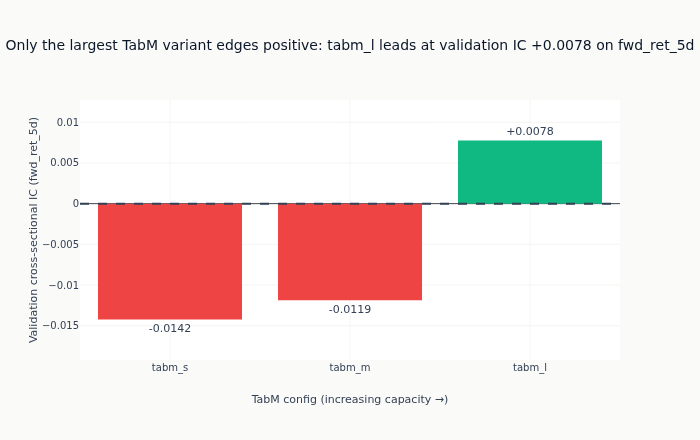

In [10]:
# Grid IC as a chart: one bar per config (ordered by capacity s -> m -> l),
# colored by IC sign so the "only the largest variant edges positive" message
# reads at a glance. The dashed line at zero is the credibility reference — a
# validation IC whose sign is not distinguishable from zero carries no standalone
# edge (the HAC intervals live in 12_model_analysis).
if grid_results:
    _order = {"tabm_s": 0, "tabm_m": 1, "tabm_l": 2}
    _ranked = sorted(grid_results, key=lambda r: _order.get(r["config_name"], 99))
    _names = [r["config_name"] for r in _ranked]
    _ics = [r["best_ic"] for r in _ranked]
    _hues = [style.COLORS["positive"] if v >= 0 else style.COLORS["negative"] for v in _ics]

    fig = go.Figure()
    fig.add_bar(
        x=_names,
        y=_ics,
        marker_color=_hues,
        text=[f"{v:+.4f}" for v in _ics],
        textposition="outside",
        cliponaxis=False,
    )
    fig.add_hline(y=0.0, line=dict(color=style.COLORS["neutral"], dash="dash"))
    fig.update_layout(
        template="ml4t",
        title=(
            f"Only the largest TabM variant edges positive: {best_name} leads at "
            f"validation IC {best_ic:+.4f} on {label_col}"
        ),
        xaxis_title="TabM config (increasing capacity →)",
        yaxis_title=f"Validation cross-sectional IC ({label_col})",
        showlegend=False,
        height=440,
    )
    _pad = max(abs(v) for v in _ics) * 0.35
    fig.update_yaxes(range=[min(_ics) - _pad, max(_ics) + _pad])
    fig.show()

## 5. Learning Curves

In [11]:
curves = result["all_learning_curves"]
if curves.height > 0:
    checkpoints = sorted(curves["epoch"].unique().to_list())
    display_cps = [cp for cp in checkpoints if cp % 50 == 0 or cp == checkpoints[-1]]

    print(f"\n{'Config':15s}", end="")
    for cp in display_cps:
        print(f" {cp:>7d}", end="")
    print()
    print("-" * (15 + 8 * len(display_cps)))

    for r in grid_results:
        cfg_data = curves.filter(pl.col("config") == r["config_name"])
        print(f"{r['config_name']:15s}", end="")
        for cp in display_cps:
            row = cfg_data.filter(pl.col("epoch") == cp)
            if row.height > 0:
                ic_val = row["ic_mean"][0]
                print(f" {ic_val:+7.4f}", end="")
            else:
                print(f" {'N/A':>7s}", end="")
        print()


Config               50     100
-------------------------------
tabm_l          +0.0054 -0.0006
tabm_m          -0.0232 -0.0194
tabm_s          -0.0149 -0.0142


## 6. Fold Metrics

In [12]:
fold_metrics = result["fold_metrics"]
if fold_metrics.height > 0:
    print(f"\nPer-fold IC ({best_name}):")
    for row in fold_metrics.iter_rows(named=True):
        print(f"  Fold {row['fold_id']}: IC={row['ic_mean']:+.4f}  n_test={row['n_test']:,}")
    mean_ic = fold_metrics["ic_mean"].mean()
    print(f"\n  Mean IC: {mean_ic:+.4f}")


Per-fold IC (tabm_l):
  Fold 0: IC=+0.0231  n_test=7,668
  Fold 1: IC=+0.0422  n_test=7,684
  Fold 2: IC=-0.0029  n_test=7,676
  Fold 3: IC=-0.0270  n_test=7,674
  Fold 4: IC=+0.0034  n_test=7,692

  Mean IC: +0.0078


## 7. Save Results

Predictions and fold metrics are registered by `run_tabm_cv()`
during training. Here we record the pipeline results JSON.

In [13]:
predictions = result["predictions"]
all_predictions = result["all_predictions"]

print(f"predictions.parquet: {predictions.height:,} rows")
print(f"all_predictions.parquet: {all_predictions.height:,} rows")
if curves.height > 0:
    print(f"learning_curves.parquet: {curves.height:,} rows")
if fold_metrics.height > 0:
    print(f"fold_metrics.parquet: {fold_metrics.height} rows")

predictions.parquet: 38,394 rows
all_predictions.parquet: 460,728 rows
learning_curves.parquet: 12 rows
fold_metrics.parquet: 5 rows


In [14]:
# Pipeline results JSON
grid_summary = {
    r["config_name"]: {
        "best_epoch": r["best_epoch"],
        "best_ic": round(r["best_ic"], 6),
        "elapsed_s": round(r["elapsed_s"], 1),
    }
    for r in grid_results
}

val_ic_mean = float(fold_metrics["ic_mean"].mean()) if fold_metrics.height > 0 else None

## 8. Key Takeaways

1. **TabM-L is the strongest tabular_dl variant**: IC +0.0078 on `fwd_ret_5d`
   (HAC 95% CI [-0.016, +0.032], $t_{HAC}=0.63$). TabM-M (-0.012) and TabM-S
   (-0.014) sit below it — with only 30 products per cross-section the smaller
   variants undertrain. All three CIs include zero, so no TabM config clears
   the credibility line.
2. **Cross-section size constrains tabular DL**: with 30 CME products per
   snapshot none of the variants learns stable feature interactions; the
   largest merely edges positive within the noise band. The performance
   ordering across families on this panel is set by what each method does with
   a thin cross-section, not by raw architectural expressiveness.
3. **The one credibility-line family on `fwd_ret_5d` is the latent-factor SDF**:
   IC +0.042 with a HAC 95% CI that excludes zero ([`12_model_analysis`](12_model_analysis.ipynb)).
   TabM and GBM sit a tier below with intervals that still include zero; the
   multi-family signal concentrates in the carry-driven SDF cross-section.

**Next**: [`09_dl_lstm`](09_dl_lstm.ipynb) tests whether sequential memory captures carry
regime transitions that flat-feature models miss.
**Book**: Chapter 12.3 discusses when tabular DL achieves higher IC than GBMs.

In [15]:
print(f"\n{'=' * 60}")
print(f"Tabular DL Grid Search: {CASE_STUDY_ID}")
print(f"{'=' * 60}")
print(f"Features: {n_features}  |  Folds: {len(splits)}  |  Label: {label_col}")
print(f"Device: {device_str}  |  Epochs: {N_EPOCHS}")
print(f"Grid: {len(tabdl_configs)} configs ({', '.join(MODELS)})")
print(f"{'-' * 60}")
print(f"Best config: {best_name} @ epoch {best_epoch}")
print(f"Validation IC (cross-sectional): {best_ic:+.4f}")
if val_ic_mean is not None:
    print(f"Mean fold IC: {val_ic_mean:+.4f}")


Tabular DL Grid Search: cme_futures
Features: 69  |  Folds: 5  |  Label: fwd_ret_5d
Device: cuda  |  Epochs: 100
Grid: 3 configs (tabm)
------------------------------------------------------------
Best config: tabm_l @ epoch 25
Validation IC (cross-sectional): +0.0078
Mean fold IC: +0.0078
